In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive shell and plot formatting as per your project requirements
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

# Set pandas options and plot styles
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (12, 8)
%matplotlib inline

# Machine Learning Libraries
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [6]:
# Read the dataset using your absolute path
df = pd.read_csv(r'C:\Users\vadde\Downloads\Project\Crop_recommendation.csv')

# Display the first few rows to ensure it loaded correctly
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


Text(0.5, 1.0, 'Ratio of Nitrogen')

Text(0.5, 1.0, 'Ratio of Phosphorous')

Text(0.5, 1.0, 'Ratio of Potassium')

Text(0.5, 1.0, 'Ratio of Temperature')

Text(0.5, 1.0, 'Ratio of Humidity')

Text(0.5, 1.0, 'Ratio of pH')

Text(0.5, 1.0, 'Ratio of Rainfall')

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

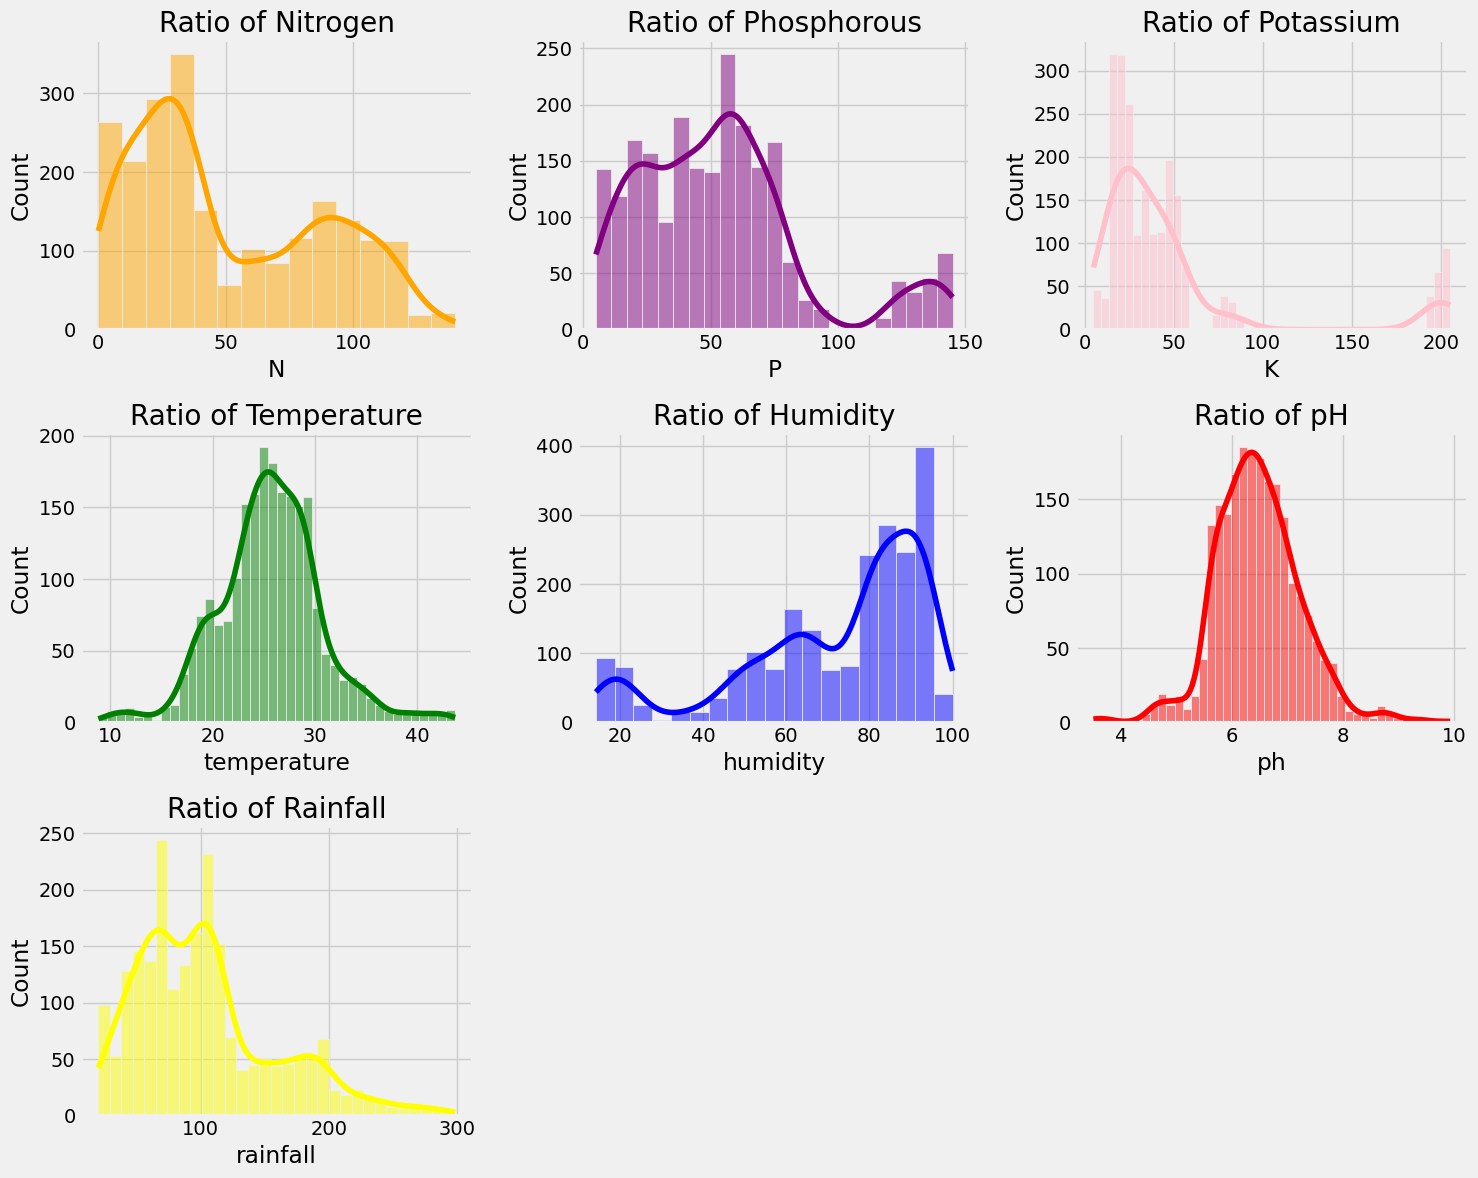

In [7]:
# Visualize the distribution of agricultural conditions
fig, ax = plt.subplots(3, 3, figsize=(15, 12))
sns.histplot(df['N'], kde=True, color='orange', ax=ax[0,0]).set_title('Ratio of Nitrogen')
sns.histplot(df['P'], kde=True, color='purple', ax=ax[0,1]).set_title('Ratio of Phosphorous')
sns.histplot(df['K'], kde=True, color='pink', ax=ax[0,2]).set_title('Ratio of Potassium')
sns.histplot(df['temperature'], kde=True, color='green', ax=ax[1,0]).set_title('Ratio of Temperature')
sns.histplot(df['humidity'], kde=True, color='blue', ax=ax[1,1]).set_title('Ratio of Humidity')
sns.histplot(df['ph'], kde=True, color='red', ax=ax[1,2]).set_title('Ratio of pH')
sns.histplot(df['rainfall'], kde=True, color='yellow', ax=ax[2,0]).set_title('Ratio of Rainfall')

# Hide empty subplots
ax[2,1].axis('off')
ax[2,2].axis('off')
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

<Axes: xlabel='humidity', ylabel='label'>

Text(0.5, 1.0, 'Crop Types vs. Humidity Levels')

Text(0.5, 0, 'Humidity')

Text(0, 0.5, 'Crop Label')

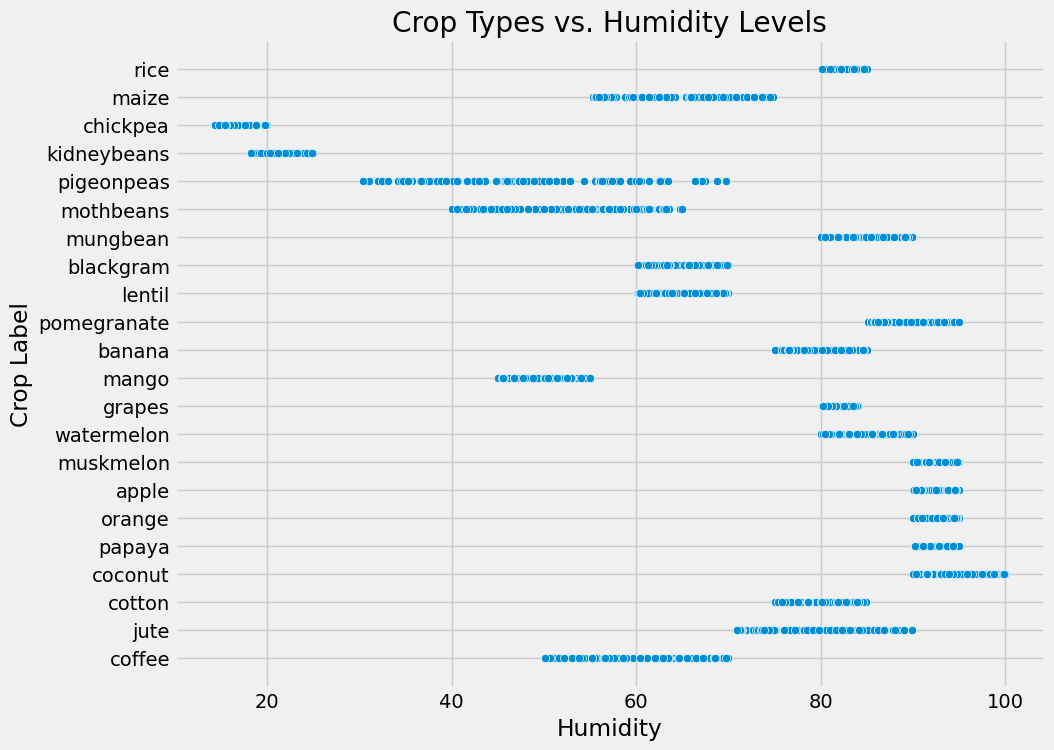

In [8]:
# Visualize the relationship between humidity and crop labels
plt.figure(figsize=(10, 8))
sns.scatterplot(x=df['humidity'], y=df['label'])
plt.title('Crop Types vs. Humidity Levels')
plt.xlabel('Humidity')
plt.ylabel('Crop Label')
plt.show()

In [9]:
# Separate features (X) and target variable (y)
X = df.drop('label', axis=1)
y = df['label']

# Split the dataset (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

Training Data Shape: (1760, 7)
Testing Data Shape: (440, 7)


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Initialize the scaler
scaler = StandardScaler()

# 2. Scale the training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Initialize and train the Logistic Regression model on the SCALED data
# (Now that it's scaled, it won't need 2000 iterations, 1000 is plenty)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# 4. Make predictions on the scaled testing data
y_pred = model.predict(X_test_scaled)

# 5. Display the Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.90      0.95      0.93        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.83      0.87      0.85        23
 kidneybeans       0.95      0.95      0.95        20
      lentil       0.85      1.00      0.92        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
   

<Figure size 1500x1000 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix for Crop Prediction')

Text(0.5, 40.583333333333286, 'Predicted Crop')

Text(90.58333333333333, 0.5, 'Actual Crop')

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5]),
 [Text(0.5, 0, 'apple'),
  Text(1.5, 0, 'banana'),
  Text(2.5, 0, 'blackgram'),
  Text(3.5, 0, 'chickpea'),
  Text(4.5, 0, 'coconut'),
  Text(5.5, 0, 'coffee'),
  Text(6.5, 0, 'cotton'),
  Text(7.5, 0, 'grapes'),
  Text(8.5, 0, 'jute'),
  Text(9.5, 0, 'kidneybeans'),
  Text(10.5, 0, 'lentil'),
  Text(11.5, 0, 'maize'),
  Text(12.5, 0, 'mango'),
  Text(13.5, 0, 'mothbeans'),
  Text(14.5, 0, 'mungbean'),
  Text(15.5, 0, 'muskmelon'),
  Text(16.5, 0, 'orange'),
  Text(17.5, 0, 'papaya'),
  Text(18.5, 0, 'pigeonpeas'),
  Text(19.5, 0, 'pomegranate'),
  Text(20.5, 0, 'rice'),
  Text(21.5, 0, 'watermelon')])

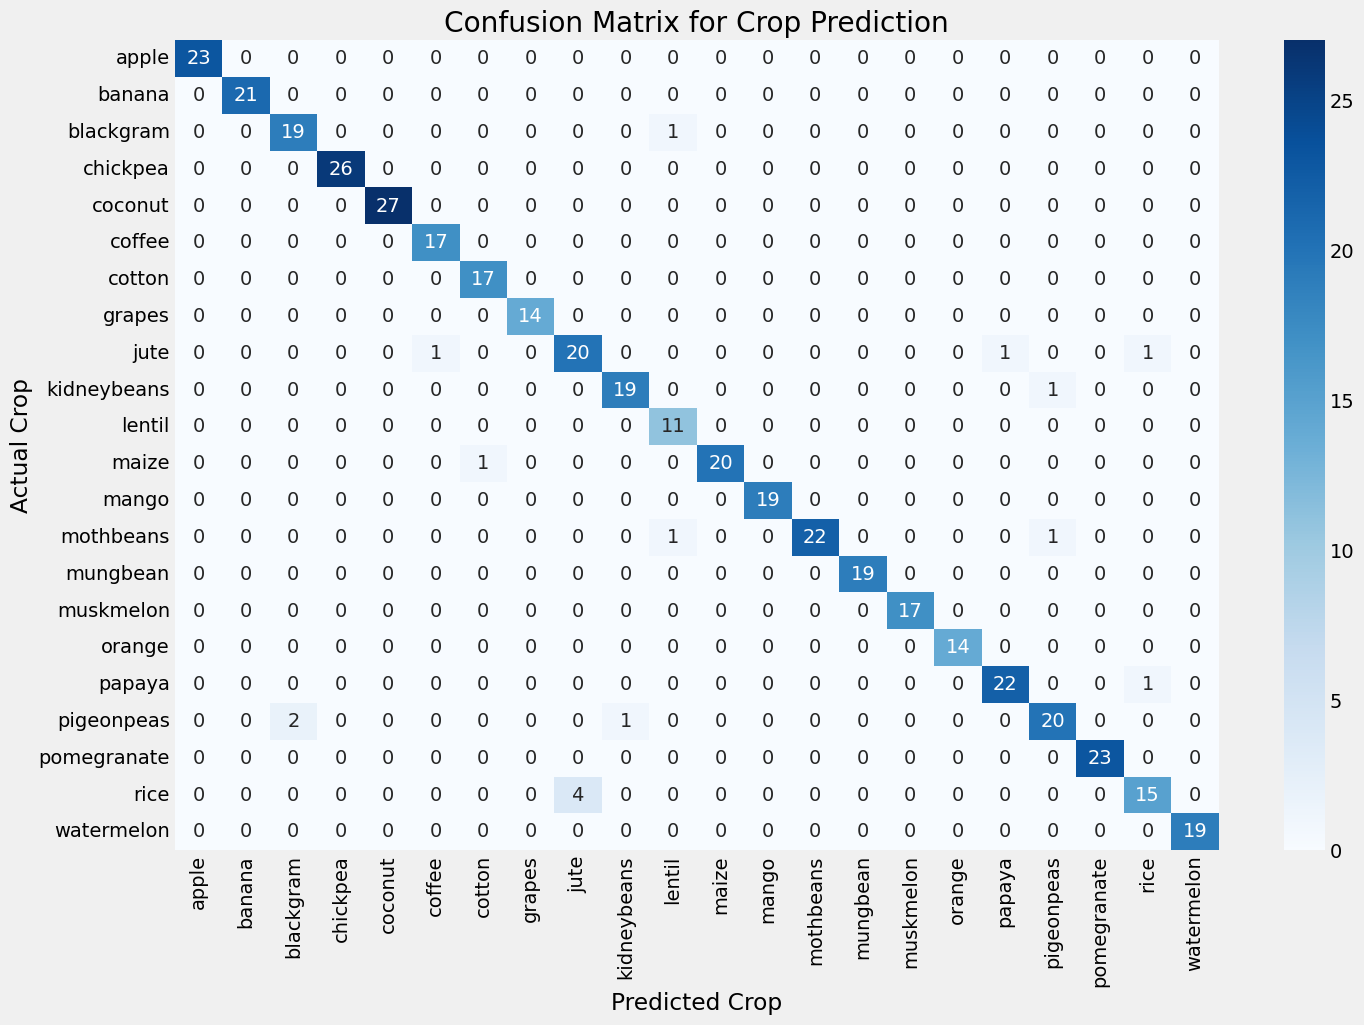

In [13]:
# Visualize the confusion matrix to see where the model makes accurate predictions
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(15, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix for Crop Prediction')
plt.xlabel('Predicted Crop')
plt.ylabel('Actual Crop')
plt.xticks(rotation=90)
plt.show()

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [26]:

# ==========================================
# 1. Data Collection & Loading
# ==========================================
# REPLACE THE TEXT INSIDE THE QUOTES ON THE LINE BELOW WITH YOUR EXACT PATH
df = pd.read_csv(r"C:\Users\vadde\Downloads\Project\Crop_recommendation.csv")

# Rename columns to match the project requirements perfectly
df = df.rename(columns={'N': 'nitrogen', 'P': 'phosphorous', 'K': 'potassium'})

# ==========================================


In [27]:
# 2. Data Pre-processing: Handling Outliers
# ==========================================
# Calculating Interquartile Range (IQR) for the phosphorous column
Q1 = df['phosphorous'].quantile(0.25)
Q3 = df['phosphorous'].quantile(0.75)
IQR = Q3 - Q1

# Defining boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering the dataframe
df_filtered = df[(df['phosphorous'] >= lower_bound) & (df['phosphorous'] <= upper_bound)]
print(f"Data shape after removing outliers: {df_filtered.shape}\n")



Data shape after removing outliers: (2062, 8)



In [28]:
# ==========================================
# 3. Extracting Seasonal Crops
# ==========================================
print("--- Seasonal Crop Recommendations ---")
summer_crops = df_filtered[(df_filtered['temperature'] > 30) & (df_filtered['humidity'] > 50)]['label'].unique()
print(f"Summer crops: {summer_crops}")

winter_crops = df_filtered[(df_filtered['temperature'] < 20) & (df_filtered['humidity'] > 30)]['label'].unique()
print(f"Winter crops: {winter_crops}")

rainy_crops = df_filtered[(df_filtered['rainfall'] > 200) & (df_filtered['humidity'] > 50)]['label'].unique()
print(f"Rainy crops: {rainy_crops}\n")



--- Seasonal Crop Recommendations ---
Summer crops: ['pigeonpeas' 'mothbeans' 'blackgram' 'mango' 'grapes' 'orange' 'papaya']
Winter crops: ['maize' 'pigeonpeas' 'lentil' 'pomegranate' 'grapes' 'orange']
Rainy crops: ['rice' 'papaya' 'coconut']



In [29]:
# ==========================================
# 4. Splitting Data into Train and Test Sets
# ==========================================
# Separating features (X) and target label (y)
X = df_filtered.drop('label', axis=1)
y = df_filtered['label']

# Splitting the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print("--- Data Split Shapes ---")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}  | y_test shape:  {y_test.shape}\n")



--- Data Split Shapes ---
X_train shape: (1649, 7) | y_train shape: (1649,)
X_test shape:  (413, 7)  | y_test shape:  (413,)



In [30]:
# ==========================================
# 5. Model Building & Evaluation
# ==========================================
print("--- Model Training & Evaluation ---")
# Initializing the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=0)

# Training the model
model.fit(X_train, y_train)

--- Model Training & Evaluation ---


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:


# Predicting on the test set
y_pred = model.predict(X_test)

# Calculating and printing accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 99.76%


In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset using your specific file path.
# Notice the 'r' right before the quote. This stands for "raw string" and ensures 
# that the backslashes (\) in your Windows path don't cause any extra errors.
file_path = r"C:\Users\vadde\Downloads\Project\Crop_recommendation.csv"
df = pd.read_csv(file_path)

# 2. Separate features (X) and the target label (y)
X = df.drop('label', axis=1)
y = df['label']

# 3. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale the features (This fixes the ConvergenceWarning bug!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully loaded and scaled!")

Data successfully loaded and scaled!


In [38]:
import os
# This line fixes the memory leak warning by telling Windows how many threads to use
os.environ["OMP_NUM_THREADS"] = "9" 

import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# ... [Rest of your K-Means code from Step 2] ...

,n_clusters,1
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


,n_clusters,2
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


,n_clusters,4
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


,n_clusters,6
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


,n_clusters,7
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


,n_clusters,8
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


,n_clusters,9
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


,n_clusters,10
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


<Figure size 1000x400 with 0 Axes>

Text(0.5, 1.0, 'The Elbow Method')

Text(0.5, 0, 'No of clusters')

Text(0, 0.5, 'WCSS')

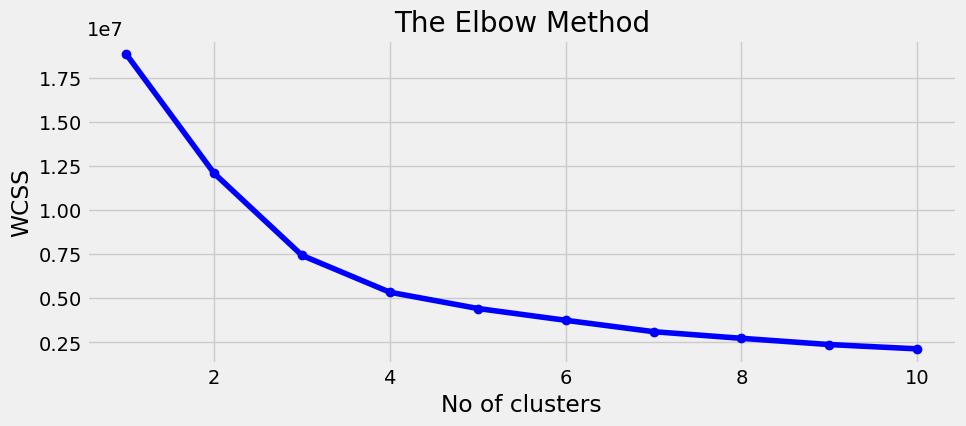

Crops in First cluster:
 ['grapes' 'apple']
Crops in Second cluster:
 ['maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans' 'mungbean'
 'blackgram' 'lentil' 'pomegranate' 'mango' 'orange' 'papaya' 'coconut']


In [39]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Apply the Elbow Method to calculate WCSS
wcss = []
for i in range(1, 11):
    # n_init='auto' is the modern standard, replacing n_init=10
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# 2. Plot the Elbow Graph
plt.figure(figsize=(10, 4))
plt.plot(range(1, 11), wcss, marker='o', color='b')
plt.title('The Elbow Method', fontsize=20)
plt.xlabel('No of clusters')
plt.ylabel('WCSS')
plt.show()

# 3. Train the K-Means model with 4 clusters (as identified in your graph)
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_kmeans = kmeans.fit_predict(X)

# 4. View which crops fall into which cluster
z = pd.concat([df['label'], pd.DataFrame(y_kmeans, columns=['cluster'])], axis=1)
print("Crops in First cluster:\n", z[z['cluster']==0]['label'].unique())
print("Crops in Second cluster:\n", z[z['cluster']==1]['label'].unique())

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Initialize the model
model = LogisticRegression()

# 2. Train the model using the SCALED training data
model.fit(X_train_scaled, y_train)

# 3. Make predictions using the SCALED test data
y_pred = model.predict(X_test_scaled)

# 4. Evaluate the model's performance metrics
cr = classification_report(y_test, y_pred)
print("Classification Report:\n", cr)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.90      0.95      0.93        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.83      0.87      0.85        23
 kidneybeans       0.95      0.95      0.95        20
      lentil       0.85      1.00      0.92        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
   

In [41]:
import pickle
import numpy as np
import warnings
warnings.filterwarnings("ignore") # Hides standard sklearn warnings

# 1. Save both the model and the scaler to your computer
pickle.dump(model, open('logistic_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
print("Model and Scaler successfully saved!")

# ---------------------------------------------------------
# HOW TO USE THE SAVED MODEL FOR A NEW PREDICTION:
# ---------------------------------------------------------

# 2. Load the saved model and scaler
loaded_model = pickle.load(open('logistic_model.pkl', 'rb'))
loaded_scaler = pickle.load(open('scaler.pkl', 'rb'))

# 3. Accept user input features in this order: 
# [Nitrogen, Phosphorus, Potassium, temperature, humidity, ph, rainfall]
user_input = np.array([[90, 42, 43, 20.8, 82.0, 6.5, 202.9]])

# 4. Scale the user's input using the loaded scaler (crucial for accurate predictions)
scaled_input = loaded_scaler.transform(user_input)

# 5. Make the final prediction
prediction = loaded_model.predict(scaled_input)
print(f"\nThe suggested crop for the given climatic condition is: '{prediction[0]}'")

Model and Scaler successfully saved!

The suggested crop for the given climatic condition is: 'rice'
